# JAX and PyTorch Backends: Quick Start

In versions 2.0.0 and above, galpy can compute with [JAX](https://docs.jax.dev/) arrays and
[PyTorch](https://pytorch.org/) tensors as well as with NumPy arrays.
Potentials, orbits, action-angle coordinates, distribution functions, and
stream models accept JAX or PyTorch inputs, compute with that framework, and
return arrays of the same kind. This means that galpy calculations can be
differentiated with automatic differentiation (`jax.grad`,
`torch.autograd`), compiled (`jax.jit`, `torch.compile`), vectorized
(`jax.vmap`), and run on a GPU. With NumPy inputs, galpy behaves as before.

This page is a short introduction. The notebooks listed at the end describe
each part of galpy in more detail.

**Installation.** The backends are optional. Install them with

```
pip install galpy[jax]    # jax, array-api-compat, and diffrax
pip install galpy[torch]  # torch, array-api-compat, torchdiffeq, and torchode
```

**Precision.** galpy computes in double precision. JAX uses single
precision unless 64-bit mode is switched on, which you should do before
creating any JAX arrays. PyTorch tensors are single precision by default;
galpy computes in double precision internally, but returns a single-precision
tensor for a single-precision input, so create double-precision tensors
(`dtype=torch.float64`) when you need the full precision.

In [1]:
%matplotlib inline
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy
import torch

import galpy.backend
from galpy.potential import (
    MWPotential2014,
    dvcircdR,
    evaluatePotentials,
    evaluateRforces,
    vcirc,
)

## How galpy chooses a backend

galpy decides which array library to compute with as follows:

1. **The data.** A call that receives a JAX array computes with JAX and
   returns a JAX array; a call that receives a PyTorch tensor computes with
   PyTorch and returns a tensor. NumPy arrays and Python numbers give NumPy
   results.
2. **The context manager** `galpy.backend.use`. When there is no array to
   dispatch on, for example when a potential is evaluated at Python floats,
   the backend set with `with galpy.backend.use("jax"):` (or `"torch"`) is
   used. Arrays passed inside the block still take precedence.
3. **The configuration file.** Outside of a `use` block, the default
   backend is set by the `default` option in the `[backend]` section of the
   [configuration file](../../installation.rst#configuration-file), which is
   `numpy` unless you change it.

For example, the radial force of `MWPotential2014` at a set of radii given
as a JAX array is a JAX array:

In [2]:
R = jnp.linspace(0.5, 2.0, 5)
FR = evaluateRforces(MWPotential2014, R, 0.0)
print(type(FR))
print(FR)

<class 'jaxlib._jax.ArrayImpl'>
[-2.04931846 -1.17102149 -0.76121158 -0.54950033 -0.42482903]


and the same call with a PyTorch tensor returns a tensor (here in double
precision):

In [3]:
Rt = torch.linspace(0.5, 2.0, 5, dtype=torch.float64)
print(evaluateRforces(MWPotential2014, Rt, 0.0))

tensor([-2.0493, -1.1710, -0.7612, -0.5495, -0.4248], dtype=torch.float64)


These are the same numbers as with NumPy:

In [4]:
print(evaluateRforces(MWPotential2014, numpy.linspace(0.5, 2.0, 5), 0.0))

[-2.04931846 -1.17102149 -0.76121158 -0.54950033 -0.42482903]


At Python floats there is nothing to dispatch on, and the `use` context
manager selects the backend:

In [5]:
print(repr(evaluatePotentials(MWPotential2014, 1.0, 0.0)))
with galpy.backend.use("jax"):
    print(repr(evaluatePotentials(MWPotential2014, 1.0, 0.0)))
with galpy.backend.use("torch"):
    Phi = evaluatePotentials(MWPotential2014, 1.0, 0.0)
print(repr(Phi))

np.float64(-1.3733506513947895)


Array(-1.37335065, dtype=float64)
tensor(-1.3734, dtype=torch.float64)


## A first derivative

Because the computation happens in JAX or PyTorch, it can be differentiated.
For example, the derivative of the circular velocity with respect to radius,
$\mathrm{d}v_c/\mathrm{d}R$, which determines the epicycle frequency and the
Oort constants, is obtained with `jax.grad`, vectorized over a grid of radii
with `jax.vmap`, and compiled with `jax.jit`:

In [6]:
def vc(R):
    return vcirc(MWPotential2014, R)


Rs = jnp.linspace(0.2, 3.0, 101)
dvcdR = jax.jit(jax.vmap(jax.grad(vc)))(Rs)

With PyTorch, the same derivative is obtained with `backward`:

In [7]:
Rt = torch.linspace(0.2, 3.0, 101, dtype=torch.float64, requires_grad=True)
vcirc(MWPotential2014, Rt).sum().backward()
print(
    "Largest difference between JAX and PyTorch:",
    numpy.max(numpy.fabs(Rt.grad.numpy() - numpy.asarray(dvcdR))),
)

Largest difference between JAX and PyTorch: 1.3322676295501878e-15


The derivative agrees with a finite difference of the NumPy rotation curve
and with galpy's analytic `dvcircdR`:

Largest difference with the finite difference: 3.5165415024351887e-10
Largest difference with dvcircdR: 1.4710455076283324e-15


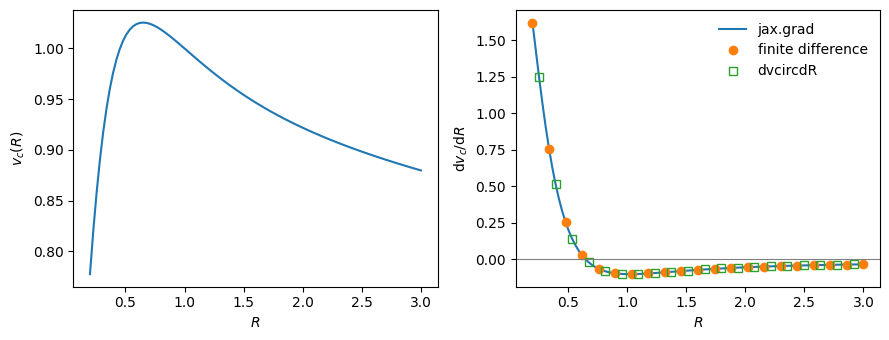

In [8]:
Rn = numpy.asarray(Rs)
h = 1e-5
dvcdR_fd = (vcirc(MWPotential2014, Rn + h) - vcirc(MWPotential2014, Rn - h)) / (2.0 * h)
dvcdR_analytic = dvcircdR(MWPotential2014, Rn)
print(
    "Largest difference with the finite difference:",
    numpy.max(numpy.fabs(numpy.asarray(dvcdR) - dvcdR_fd)),
)
print(
    "Largest difference with dvcircdR:",
    numpy.max(numpy.fabs(numpy.asarray(dvcdR) - dvcdR_analytic)),
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.plot(Rs, jax.vmap(vc)(Rs))
ax1.set_xlabel(r"$R$")
ax1.set_ylabel(r"$v_c(R)$")
ax2.plot(Rs, dvcdR, label=r"jax.grad")
ax2.plot(Rn[::5], dvcdR_fd[::5], "o", label=r"finite difference")
ax2.plot(Rn[2::5], dvcdR_analytic[2::5], "s", mfc="none", label=r"dvcircdR")
ax2.axhline(0.0, color="0.5", lw=0.8)
ax2.set_xlabel(r"$R$")
ax2.set_ylabel(r"$\mathrm{d}v_c/\mathrm{d}R$")
ax2.legend(frameon=False)
fig.tight_layout()

Derivatives with respect to the parameters of a potential work in the same
way: give the parameter as a JAX value (as `jax.grad` does) or as a PyTorch
tensor with `requires_grad=True`. See the [potentials
notebook](../potentials/backends.ipynb) for this and much more.

## Things to keep in mind

* Build an `Orbit` from a backend array, e.g.,
  `Orbit(jnp.array([1.0, 0.1, 1.1, 0.0, 0.05, 0.0]))`, or from Python floats
  inside a `galpy.backend.use("jax")` (or `"torch"`) block, and integrate it
  with `method="diffrax"` (JAX) or `method="torchode"` / `method="torchdiffeq"`
  (PyTorch) to differentiate with respect to the potential's parameters.
* Samplers take an explicit random key: `key=galpy.backend.random.key(seed,
  backend="jax")` (or `backend="torch"`). Without a key, they draw from
  NumPy's global random-number generator as before.
* galpy never compiles anything itself. Wrap your own function, which
  contains galpy calls, in `jax.jit` or `torch.compile`.
* `astropy` `Quantity` inputs and outputs work with the backends outside of
  compiled functions, but a parameter given as a backend array has no units
  and is in galpy's natural units.

## Where to go next

* [Potentials](../potentials/backends.ipynb): evaluating potentials on backend arrays,
  derivatives with respect to coordinates and parameters, `jax.jit` and
  `jax.vmap`, PyTorch's autograd, GPUs, and writing a new potential that
  works with every backend.
* [Orbits](../orbits/backends.ipynb): integrating orbits with diffrax, torchode, and
  torchdiffeq, derivatives with respect to the initial conditions and the
  potential, galpy's C integrators with their state-transition matrix,
  batches of orbits, forward and reverse mode, and GPUs.
* [Action-angle coordinates](../action_angle/backends.ipynb): derivatives of Staeckel,
  adiabatic, spherical, and isochrone-approximation actions, the focal-length
  estimate, and the differentiable inverse transformation of
  `actionAngleVerticalInverse`.
* [Distribution functions](../distribution_functions/backends.ipynb): constructing,
  evaluating, and sampling spherical and disk distribution functions with
  random keys, and derivatives of samples and of the King model.
* [Streams: streamdf and stream gaps](../streams/backends_streamdf.ipynb):
  constructing the action-angle stream model in JAX (also under
  `jax.jit`), its track and the track's derivative with respect to the
  potential, sampling and evaluating it on the backends, and stream gaps and
  their derivatives with respect to the subhalo's parameters.
* [Streams: particle spray](../streams/backends_streamspraydf.ipynb):
  particle-spray streams and their tracks under `jax.jit`, and their
  derivatives with respect to the potential.